# Week 3: Token-Level Direct Classification

## Research-Grade Implementation

### Goal
Directly classify **what tokens are causing high entropy** rather than using SEP as a proxy.

### Key Insight
- **SEP (Proxy)**: Classifies the prompt -> "Is this prompt in code mode?"
- **Token-Level (Direct)**: Classifies candidate tokens -> "Are the tokens causing entropy code tokens?"

### Architecture
```
User Prompt -> Generate -> High Entropy Detected?
                              | YES
                         Get Top-K Candidate Tokens
                              |
                         For each candidate token:
                           - Form completion: prompt + token
                           - Get hidden state at layer 28
                           - Classify: CODE or LANGUAGE token?
                              |
                         Weighted Voting:
                           code_score = sum p(token) * is_code(token)
                           lang_score = sum p(token) * is_lang(token)
                              |
                         code_score > lang_score?
                              |
                         YES -> Trigger Code Retrieval
                         NO  -> Continue Generation
```

---

## Part 1: Setup & Configuration

In [1]:
# Cell 1.1: Install dependencies
!pip install -q transformers torch accelerate scipy scikit-learn pandas matplotlib seaborn tqdm

In [2]:
# Cell 1.2: Imports and reproducibility
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Dict, List, Tuple, Optional
from transformers import AutoTokenizer, AutoModelForCausalLM
from scipy.stats import entropy as scipy_entropy
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_predict, learning_curve
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
from sklearn.calibration import calibration_curve
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from tqdm.notebook import tqdm
import time
import pickle
import warnings
warnings.filterwarnings('ignore')

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Imports complete")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")

Imports complete
PyTorch version: 2.9.0+cu126
CUDA available: True
CUDA device: Tesla T4


In [3]:
# Cell 1.3: Load Model
MODEL_NAME = "codellama/CodeLlama-7b-Instruct-hf"
print(f"Loading {MODEL_NAME}...")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16,
    device_map="auto",
    low_cpu_mem_usage=True,
    output_hidden_states=True
)
model.eval()

# Get model info
NUM_LAYERS = model.config.num_hidden_layers
HIDDEN_SIZE = model.config.hidden_size
VOCAB_SIZE = model.config.vocab_size

print(f"\nModel loaded successfully!")
print(f"  Layers: {NUM_LAYERS}")
print(f"  Hidden size: {HIDDEN_SIZE}")
print(f"  Vocab size: {VOCAB_SIZE:,}")
print(f"  Device: {next(model.parameters()).device}")

Loading codellama/CodeLlama-7b-Instruct-hf...


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/411 [00:00<?, ?B/s]

...

model-00002-of-00002.safetensors:   0%|          | 0.00/3.50G [00:00<?, ?B/s]

The following generation flags are not valid and may be ignored: ['output_hidden_states']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/116 [00:00<?, ?B/s]


Model loaded successfully!
  Layers: 32
  Hidden size: 4096
  Vocab size: 32,016
  Device: cuda:0


In [4]:
# Cell 1.4: Configuration constants

# Layer configuration (from Week3_All_Layers_Analysis)
BEST_LAYER = 28  # Best overall OOD accuracy (92.3%)
MULTI_LAYERS = [8, 16, 28]  # For multi-layer experiments

# Inference configuration
DEFAULT_TOP_K = 10  # Number of candidate tokens to analyze
ENTROPY_THRESHOLD = 3.0  # Bits - trigger analysis above this
VOTE_THRESHOLD = 0.5  # Code vote proportion to trigger retrieval

# Training configuration
CV_FOLDS = 5
MAX_ITER = 1000

print("Configuration:")
print(f"  Best layer: {BEST_LAYER}")
print(f"  Multi-layers: {MULTI_LAYERS}")
print(f"  Top-K candidates: {DEFAULT_TOP_K}")
print(f"  Entropy threshold: {ENTROPY_THRESHOLD} bits")
print(f"  Vote threshold: {VOTE_THRESHOLD}")
print(f"  CV folds: {CV_FOLDS}")

Configuration:
  Best layer: 28
  Multi-layers: [8, 16, 28]
  Top-K candidates: 10
  Entropy threshold: 3.0 bits
  Vote threshold: 0.5
  CV folds: 5


---

## Part 2: Training Data Generation (800+ Examples)

Generate labeled `(prompt, token, full_text, label)` tuples inline.

**Data Format:**
```python
{
    "prompt": "The authentication is done using",
    "next_token": "the",
    "full_text": "The authentication is done usingthe",
    "label": "language",  # or "code"
    "category": "auth_method"
}
```

In [5]:
# Cell 2.1: CODE Context Prompts (~50 unique prompts)

CODE_CONTEXT_PROMPTS = [
    # ===== PYTHON IMPORTS =====
    {"prompt": "import ", "category": "import"},
    {"prompt": "from sklearn import ", "category": "import"},
    {"prompt": "from tensorflow.", "category": "import"},
    {"prompt": "from torch import ", "category": "import"},
    {"prompt": "import pandas as ", "category": "import"},
    {"prompt": "from numpy import ", "category": "import"},
    {"prompt": "from flask import ", "category": "import"},
    {"prompt": "from django.", "category": "import"},
    {"prompt": "import requests\nfrom ", "category": "import"},
    {"prompt": "from transformers import ", "category": "import"},

    # ===== METHOD CALLS =====
    {"prompt": "result = np.", "category": "method_call"},
    {"prompt": "df.", "category": "method_call"},
    {"prompt": "model.", "category": "method_call"},
    {"prompt": "response = requests.", "category": "method_call"},
    {"prompt": "data = json.", "category": "method_call"},
    {"prompt": "plt.", "category": "method_call"},
    {"prompt": "torch.", "category": "method_call"},
    {"prompt": "tf.", "category": "method_call"},
    {"prompt": "os.", "category": "method_call"},
    {"prompt": "sys.", "category": "method_call"},

    # ===== VARIABLE ASSIGNMENTS =====
    {"prompt": "x = ", "category": "assignment"},
    {"prompt": "config = ", "category": "assignment"},
    {"prompt": "result = ", "category": "assignment"},
    {"prompt": "output = ", "category": "assignment"},
    {"prompt": "data = ", "category": "assignment"},

    # ===== FUNCTION/CLASS DEFINITIONS =====
    {"prompt": "def ", "category": "definition"},
    {"prompt": "class ", "category": "definition"},
    {"prompt": "async def ", "category": "definition"},
    {"prompt": "def __init__(self, ", "category": "definition"},
    {"prompt": "@staticmethod\ndef ", "category": "definition"},

    # ===== CONTROL FLOW =====
    {"prompt": "if x ", "category": "control_flow"},
    {"prompt": "for item in ", "category": "control_flow"},
    {"prompt": "while True:\n    ", "category": "control_flow"},
    {"prompt": "return self.", "category": "control_flow"},
    {"prompt": "yield ", "category": "control_flow"},

    # ===== RUST =====
    {"prompt": "fn ", "category": "rust"},
    {"prompt": "let mut ", "category": "rust"},
    {"prompt": "pub struct ", "category": "rust"},
    {"prompt": "impl ", "category": "rust"},
    {"prompt": "use std::", "category": "rust"},

    # ===== GO =====
    {"prompt": "func ", "category": "go"},
    {"prompt": "package main\nimport ", "category": "go"},
    {"prompt": "type ", "category": "go"},
    {"prompt": "err := ", "category": "go"},

    # ===== TYPESCRIPT/JAVASCRIPT =====
    {"prompt": "interface ", "category": "typescript"},
    {"prompt": "const ", "category": "typescript"},
    {"prompt": "export function ", "category": "typescript"},
    {"prompt": "type Props = ", "category": "typescript"},
    {"prompt": "import { useState } from ", "category": "typescript"},
]

print(f"CODE context prompts: {len(CODE_CONTEXT_PROMPTS)}")

CODE context prompts: 49


In [6]:
# Cell 2.2: LANGUAGE Context Prompts (~50 unique prompts)

LANGUAGE_CONTEXT_PROMPTS = [
    # ===== COMMENTS =====
    {"prompt": "# This function ", "category": "comment"},
    {"prompt": "# TODO: ", "category": "comment"},
    {"prompt": "// This method ", "category": "comment"},
    {"prompt": "/* The purpose of this ", "category": "comment"},
    {"prompt": "# Note: ", "category": "comment"},
    {"prompt": "// FIXME: ", "category": "comment"},
    {"prompt": "# WARNING: ", "category": "comment"},
    {"prompt": "/// This ", "category": "comment"},
    {"prompt": "# @param ", "category": "comment"},
    {"prompt": "// Returns ", "category": "comment"},

    # ===== DOCSTRINGS =====
    {"prompt": '"""', "category": "docstring"},
    {"prompt": "'''This function ", "category": "docstring"},
    {"prompt": '"""\n    Args:\n        ', "category": "docstring"},
    {"prompt": "Returns:", "category": "docstring"},
    {"prompt": "Raises:", "category": "docstring"},
    {"prompt": "Example:", "category": "docstring"},
    {"prompt": "Note:", "category": "docstring"},
    {"prompt": "Parameters:\n    ", "category": "docstring"},

    # ===== STRING LITERALS =====
    {"prompt": "print('Error: ", "category": "string"},
    {"prompt": 'logger.info("Processing ', "category": "string"},
    {"prompt": "raise ValueError('", "category": "string"},
    {"prompt": 'message = "The ', "category": "string"},
    {"prompt": "print(f'Successfully ", "category": "string"},
    {"prompt": 'logging.error("Failed to ', "category": "string"},
    {"prompt": "raise TypeError('", "category": "string"},
    {"prompt": 'print("Warning: ', "category": "string"},

    # ===== ERROR MESSAGES =====
    {"prompt": "ImportError: No module named ", "category": "error"},
    {"prompt": "TypeError: expected ", "category": "error"},
    {"prompt": "AttributeError: '", "category": "error"},
    {"prompt": "ValueError: invalid ", "category": "error"},
    {"prompt": "KeyError: '", "category": "error"},
    {"prompt": "IndexError: list index ", "category": "error"},
    {"prompt": "RuntimeError: ", "category": "error"},
    {"prompt": "FileNotFoundError: ", "category": "error"},

    # ===== EXPLANATIONS =====
    {"prompt": "The algorithm ", "category": "explanation"},
    {"prompt": "This function ", "category": "explanation"},
    {"prompt": "The main purpose is to ", "category": "explanation"},
    {"prompt": "This code ", "category": "explanation"},
    {"prompt": "The implementation ", "category": "explanation"},
    {"prompt": "We need to ", "category": "explanation"},
    {"prompt": "The approach is to ", "category": "explanation"},
    {"prompt": "In this case, ", "category": "explanation"},

    # ===== NATURAL LANGUAGE =====
    {"prompt": "The weather today is ", "category": "natural"},
    {"prompt": "My favorite color is ", "category": "natural"},
    {"prompt": "The meeting was ", "category": "natural"},
    {"prompt": "I think that ", "category": "natural"},
    {"prompt": "The book is about ", "category": "natural"},
]

print(f"LANGUAGE context prompts: {len(LANGUAGE_CONTEXT_PROMPTS)}")

LANGUAGE context prompts: 47


In [7]:
# Cell 2.3: Token Banks

# CODE tokens - identifiers, keywords, symbols that indicate code
CODE_TOKENS = {
    "import": ["numpy", "pandas", "torch", "sklearn", "tensorflow", "requests", "json", "os", "sys", "re",
               "flask", "django", "fastapi", "boto3", "scipy", "matplotlib", "seaborn", "cv2", "PIL", "keras"],
    "method_call": ["fit", "predict", "transform", "load", "save", "get", "post", "read", "write", "append",
                    "train", "eval", "forward", "backward", "compile", "run", "execute", "parse", "dump", "loads"],
    "assignment": ["calculate", "process", "fetch", "load", "create", "initialize", "build", "parse", "get",
                   "compute", "generate", "validate", "transform", "convert", "encode", "decode", "serialize"],
    "definition": ["main", "init", "process", "handle", "calculate", "fetch", "validate", "serialize",
                   "get", "set", "update", "delete", "create", "read", "parse", "format", "convert", "build"],
    "control_flow": ["==", "!=", ">=", "<=", "is", "in", "not", "and", "or", "True", "False", "None",
                     "items", "keys", "values", "range", "enumerate", "zip", "map", "filter"],
    "rust": ["main", "new", "unwrap", "expect", "iter", "map", "filter", "collect", "clone", "into",
             "Option", "Result", "Vec", "String", "Box", "Rc", "Arc", "Mutex"],
    "go": ["main", "init", "handle", "New", "Get", "Post", "Error", "String", "Int", "Bool",
           "Println", "Printf", "Sprintf", "Marshal", "Unmarshal"],
    "typescript": ["User", "Props", "State", "Action", "Reducer", "Component", "Service", "Module",
                   "Interface", "Type", "Enum", "Class", "Function", "React", "useState", "useEffect"],
}

# LANGUAGE tokens - natural language words
LANGUAGE_TOKENS = {
    "comment": ["calculates", "returns", "handles", "processes", "validates", "checks", "converts", "formats",
                "computes", "generates", "creates", "initializes", "transforms", "parses", "builds", "loads"],
    "docstring": ["Returns", "Args", "Raises", "Example", "Note", "Warning", "Parameters", "Attributes",
                  "This", "The", "A", "An", "If", "When", "For", "None", "True", "False"],
    "string": ["invalid", "missing", "error", "success", "failed", "completed", "processing", "loading",
               "starting", "finished", "found", "not", "unable", "cannot", "should", "must", "will"],
    "error": ["module", "attribute", "type", "value", "key", "index", "name", "syntax", "file", "path",
              "object", "string", "integer", "list", "dict", "tuple", "function", "class", "method"],
    "explanation": ["works", "returns", "takes", "processes", "handles", "calculates", "converts", "validates",
                    "is", "does", "has", "can", "will", "should", "must", "may", "might"],
    "natural": ["the", "a", "an", "this", "that", "these", "those", "is", "are", "was", "were",
                "good", "bad", "great", "nice", "wonderful", "terrible", "interesting", "boring"],
}

print(f"CODE token categories: {len(CODE_TOKENS)}")
print(f"LANGUAGE token categories: {len(LANGUAGE_TOKENS)}")
print(f"Total CODE tokens: {sum(len(v) for v in CODE_TOKENS.values())}")
print(f"Total LANGUAGE tokens: {sum(len(v) for v in LANGUAGE_TOKENS.values())}")

CODE token categories: 8
LANGUAGE token categories: 6
Total CODE tokens: 144
Total LANGUAGE tokens: 106


In [8]:
# Cell 2.4: Programmatic Data Generation

def generate_training_data():
    """Generate 800+ labeled (prompt, token) examples."""
    data = []

    # Common language tokens that can appear in any context
    common_lang_tokens = ["the", "a", "an", "is", "to", "and", "or", "for", "in", "of"]
    common_code_tokens = ["numpy", "pandas", "def", "class", "import", "self", "None", "True", "False"]

    # For each CODE context prompt, generate examples
    for prompt_info in CODE_CONTEXT_PROMPTS:
        prompt = prompt_info["prompt"]
        category = prompt_info["category"]

        # Get tokens for this category, or use default
        code_tokens = CODE_TOKENS.get(category, CODE_TOKENS["assignment"])

        # Add CODE tokens (label=code) - these are the correct next tokens for code context
        for token in code_tokens[:8]:  # Take up to 8 tokens per prompt
            data.append({
                "prompt": prompt,
                "next_token": token,
                "full_text": prompt + token,
                "label": "code",
                "category": category
            })

        # Add some LANGUAGE tokens that might appear (label=language)
        for token in common_lang_tokens[:4]:
            data.append({
                "prompt": prompt,
                "next_token": token,
                "full_text": prompt + token,
                "label": "language",
                "category": category
            })

    # For each LANGUAGE context prompt, generate examples
    for prompt_info in LANGUAGE_CONTEXT_PROMPTS:
        prompt = prompt_info["prompt"]
        category = prompt_info["category"]

        # Get tokens for this category, or use default
        lang_tokens = LANGUAGE_TOKENS.get(category, LANGUAGE_TOKENS["natural"])

        # Add LANGUAGE tokens (label=language)
        for token in lang_tokens[:8]:
            data.append({
                "prompt": prompt,
                "next_token": token,
                "full_text": prompt + token,
                "label": "language",
                "category": category
            })

        # Add some CODE tokens that might appear (label=code)
        for token in common_code_tokens[:3]:
            data.append({
                "prompt": prompt,
                "next_token": token,
                "full_text": prompt + token,
                "label": "code",
                "category": category
            })

    return pd.DataFrame(data)

# Generate base dataset
df_base = generate_training_data()
print(f"Generated {len(df_base)} base training examples")
print(f"  CODE: {(df_base['label']=='code').sum()}")
print(f"  LANGUAGE: {(df_base['label']=='language').sum()}")
print(f"  Categories: {df_base['category'].nunique()}")

Generated 1105 base training examples
  CODE: 533
  LANGUAGE: 572
  Categories: 14


In [10]:
# Cell 2.5: Edge Cases (Hard Examples)

EDGE_CASES = [
    # ===== COMMENTS WITH CODE KEYWORDS (should be LANGUAGE) =====
    {"prompt": "# import numpy as ", "next_token": "np", "label": "language", "category": "edge_comment"},
    {"prompt": "# def process_data", "next_token": "(", "label": "language", "category": "edge_comment"},
    {"prompt": "// TODO: implement ", "next_token": "auth", "label": "language", "category": "edge_comment"},
    {"prompt": "# class User", "next_token": "Model", "label": "language", "category": "edge_comment"},
    {"prompt": "/* import ", "next_token": "pandas", "label": "language", "category": "edge_comment"},
    {"prompt": "// const x = ", "next_token": "5", "label": "language", "category": "edge_comment"},
    {"prompt": "# return self.", "next_token": "config", "label": "language", "category": "edge_comment"},
    {"prompt": "// fn main", "next_token": "(", "label": "language", "category": "edge_comment"},
    {"prompt": "# result = np.", "next_token": "array", "label": "language", "category": "edge_comment"},
    {"prompt": "/* def ", "next_token": "init", "label": "language", "category": "edge_comment"},

    # ===== ERROR MESSAGES (should be LANGUAGE) =====
    {"prompt": "ImportError: No module named ", "next_token": "'numpy'", "label": "language", "category": "edge_error"},
    {"prompt": "TypeError: expected ", "next_token": "string", "label": "language", "category": "edge_error"},
    {"prompt": "AttributeError: 'NoneType' has no attribute ", "next_token": "'", "label": "language", "category": "edge_error"},
    {"prompt": "ValueError: invalid literal for int() with base ", "next_token": "10", "label": "language", "category": "edge_error"},
    {"prompt": "KeyError: '", "next_token": "user_id", "label": "language", "category": "edge_error"},
    {"prompt": "ModuleNotFoundError: No module named ", "next_token": "'torch'", "label": "language", "category": "edge_error"},
    {"prompt": "NameError: name '", "next_token": "x", "label": "language", "category": "edge_error"},
    {"prompt": "SyntaxError: invalid syntax at line ", "next_token": "42", "label": "language", "category": "edge_error"},
    {"prompt": "RuntimeError: CUDA out of memory. Tried to allocate ", "next_token": "2", "label": "language", "category": "edge_error"},
    {"prompt": "AssertionError: Expected ", "next_token": "True", "label": "language", "category": "edge_error"},

    # ===== STRING LITERALS WITH CODE CONTENT (should be LANGUAGE) =====
    {"prompt": "print('import ", "next_token": "numpy", "label": "language", "category": "edge_string"},
    {"prompt": 'message = "def ', "next_token": "function", "label": "language", "category": "edge_string"},
    {"prompt": "error_msg = 'class ", "next_token": "User", "label": "language", "category": "edge_string"},
    {"prompt": 'log.info("result = np.', "next_token": "array", "label": "language", "category": "edge_string"},
    {"prompt": "template = f'import {{'", "next_token": "module", "label": "language", "category": "edge_string"},
    {"prompt": "regex = r'^def ", "next_token": "\\w", "label": "language", "category": "edge_string"},
    {"prompt": 'hint = "Try using np.', "next_token": "array", "label": "language", "category": "edge_string"},
    {"prompt": "doc = 'Parameters: x, y, z'", "next_token": "\n", "label": "language", "category": "edge_string"},

    # ===== MARKDOWN CODE BLOCKS (content IS CODE) =====
    {"prompt": "```python\nimport ", "next_token": "numpy", "label": "code", "category": "edge_markdown"},
    {"prompt": "```\ndef ", "next_token": "main", "label": "code", "category": "edge_markdown"},
    {"prompt": "```rust\nfn ", "next_token": "main", "label": "code", "category": "edge_markdown"},
    {"prompt": "```typescript\ninterface ", "next_token": "User", "label": "code", "category": "edge_markdown"},
    {"prompt": "```go\nfunc ", "next_token": "main", "label": "code", "category": "edge_markdown"},

    # ===== MIXED CONTEXTS =====
    {"prompt": "The function np.", "next_token": "array", "label": "code", "category": "edge_mixed"},
    {"prompt": "Use import ", "next_token": "pandas", "label": "code", "category": "edge_mixed"},
    {"prompt": "Call model.", "next_token": "fit", "label": "code", "category": "edge_mixed"},
    {"prompt": "First, def ", "next_token": "process", "label": "code", "category": "edge_mixed"},
    {"prompt": "Simply torch.", "next_token": "load", "label": "code", "category": "edge_mixed"},

    # ===== DOCSTRING EDGE CASES =====
    {"prompt": "\"\"\"import numpy as np\"\"\"\n", "next_token": "import", "label": "code", "category": "edge_docstring"},
    {"prompt": "'''Returns the np.", "next_token": "array", "label": "language", "category": "edge_docstring"},
    {"prompt": "\"\"\"\n    Example:\n        >>> import ", "next_token": "numpy", "label": "language", "category": "edge_docstring"},
    {"prompt": "'''\n    def process(x):\n        return ", "next_token": "x", "label": "language", "category": "edge_docstring"},

    # ===== TECHNICAL VS NON-TECHNICAL =====
    {"prompt": "The library in my town has ", "next_token": "many", "label": "language", "category": "edge_ambiguous"},
    {"prompt": "The function of the heart is ", "next_token": "to", "label": "language", "category": "edge_ambiguous"},
    {"prompt": "Running the marathon takes ", "next_token": "endurance", "label": "language", "category": "edge_ambiguous"},
    {"prompt": "The class reunion was ", "next_token": "great", "label": "language", "category": "edge_ambiguous"},
    {"prompt": "Implementing the new policy will ", "next_token": "require", "label": "language", "category": "edge_ambiguous"},
]

print(f"Edge cases: {len(EDGE_CASES)}")
df_edge = pd.DataFrame(EDGE_CASES)
print(f"  CODE: {(df_edge['label'] == 'code').sum()}")
print(f"  LANGUAGE: {(df_edge['label'] == 'language').sum()}")


Edge cases: 47
  CODE: 11
  LANGUAGE: 36


In [11]:
# Cell 2.6: Final Dataset Assembly

# Combine all data sources
df_all = pd.concat([df_base, df_edge], ignore_index=True)

# Ensure full_text column exists
df_all['full_text'] = df_all['prompt'] + df_all['next_token']

# Convert labels to binary
df_all['label_binary'] = df_all['label'].map({'language': 0, 'code': 1})

# Shuffle
df_all = df_all.sample(frac=1, random_state=SEED).reset_index(drop=True)

print("="*60)
print("FINAL TRAINING DATASET")
print("="*60)
print(f"\nTotal examples: {len(df_all)}")
print(f"  CODE: {(df_all['label']=='code').sum()} ({(df_all['label']=='code').mean()*100:.1f}%)")
print(f"  LANGUAGE: {(df_all['label']=='language').sum()} ({(df_all['label']=='language').mean()*100:.1f}%)")
print(f"  Categories: {df_all['category'].nunique()}")

print(f"\nCategory distribution:")
print(df_all['category'].value_counts().head(10))

print(f"\nSample entries:")
print(df_all[['full_text', 'label', 'category']].head(10))

FINAL TRAINING DATASET

Total examples: 1152
  CODE: 544 (47.2%)
  LANGUAGE: 608 (52.8%)
  Categories: 21

Category distribution:
category
method_call    120
import         120
comment        110
string          88
docstring       88
explanation     88
error           88
assignment      60
typescript      60
rust            60
Name: count, dtype: int64

Sample entries:
                      full_text     label     category
0              data = json.post      code  method_call
1                  Example:Args  language    docstring
2  import { useState } from the  language   typescript
3                 x = calculate      code   assignment
4   '''This function Parameters  language    docstring
5                  os.transform      code  method_call
6  /* The purpose of this numpy      code      comment
7         export function State      code   typescript
8     @staticmethod\ndef handle      code   definition
9           async def calculate      code   definition


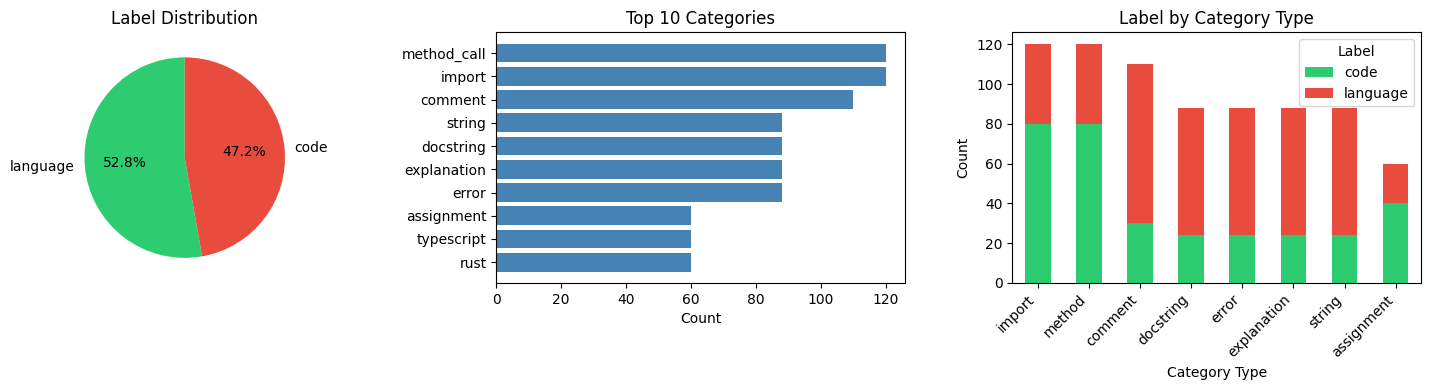


Dataset ready for training!


In [12]:
# Cell 2.7: Visualize Dataset Distribution

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot 1: Label distribution
ax1 = axes[0]
label_counts = df_all['label'].value_counts()
colors = ['#2ecc71', '#e74c3c']
ax1.pie(label_counts, labels=label_counts.index, autopct='%1.1f%%', colors=colors, startangle=90)
ax1.set_title('Label Distribution')

# Plot 2: Category distribution (top 10)
ax2 = axes[1]
cat_counts = df_all['category'].value_counts().head(10)
ax2.barh(range(len(cat_counts)), cat_counts.values, color='steelblue')
ax2.set_yticks(range(len(cat_counts)))
ax2.set_yticklabels(cat_counts.index)
ax2.set_xlabel('Count')
ax2.set_title('Top 10 Categories')
ax2.invert_yaxis()

# Plot 3: Label by category type
ax3 = axes[2]
# Group categories into types
df_all['cat_type'] = df_all['category'].apply(lambda x: 'edge' if x.startswith('edge') else x.split('_')[0] if '_' in x else x)
ct = pd.crosstab(df_all['cat_type'], df_all['label'])
ct_top = ct.loc[ct.sum(axis=1).nlargest(8).index]
ct_top.plot(kind='bar', ax=ax3, color=['#2ecc71', '#e74c3c'], stacked=True)
ax3.set_xlabel('Category Type')
ax3.set_ylabel('Count')
ax3.set_title('Label by Category Type')
ax3.legend(title='Label')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.savefig('week3_tokenlevel_data_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nDataset ready for training!")

---

## Part 3: Feature Extraction

Extract hidden states from the model for each (prompt + token) example.

In [13]:
# Cell 3.1: Hidden State Extraction Functions

def get_hidden_state(text: str, layer: int = BEST_LAYER) -> np.ndarray:
    """Extract hidden state for a text at specified layer."""
    inputs = tokenizer(text, return_tensors="pt").to(model.device)

    with torch.no_grad():
        outputs = model(**inputs, output_hidden_states=True)

    # Get hidden state at the last token position from specified layer
    # outputs.hidden_states[0] is embedding, [1] is layer 1, etc.
    hidden = outputs.hidden_states[layer][0, -1, :].cpu().numpy()
    return hidden.astype(np.float32)


def get_multi_layer_hidden_state(text: str, layers: List[int] = MULTI_LAYERS) -> np.ndarray:
    """Extract and concatenate hidden states from multiple layers."""
    inputs = tokenizer(text, return_tensors="pt").to(model.device)

    with torch.no_grad():
        outputs = model(**inputs, output_hidden_states=True)

    states = []
    for layer in layers:
        h = outputs.hidden_states[layer][0, -1, :].cpu().numpy()
        states.append(h)

    return np.concatenate(states).astype(np.float32)


# Test extraction
test_text = "import numpy"
test_h = get_hidden_state(test_text)
test_h_multi = get_multi_layer_hidden_state(test_text)

print(f"Single layer hidden state shape: {test_h.shape}")
print(f"Multi-layer hidden state shape: {test_h_multi.shape}")
print(f"Hidden state dtype: {test_h.dtype}")

Single layer hidden state shape: (4096,)
Multi-layer hidden state shape: (12288,)
Hidden state dtype: float32


In [14]:
# Cell 3.2: Extract Features for All Training Examples

print(f"Extracting hidden states from layer {BEST_LAYER} for {len(df_all)} examples...")
print("This may take several minutes...\n")

X_train = []
y_train = []

for idx, row in tqdm(df_all.iterrows(), total=len(df_all), desc="Extracting"):
    h = get_hidden_state(row['full_text'], layer=BEST_LAYER)
    X_train.append(h)
    y_train.append(row['label_binary'])

X_train = np.array(X_train)
y_train = np.array(y_train)

print(f"\nFeature extraction complete!")
print(f"  X shape: {X_train.shape}")
print(f"  y shape: {y_train.shape}")
print(f"  Memory: {X_train.nbytes / 1024 / 1024:.1f} MB")

Extracting hidden states from layer 28 for 1152 examples...
This may take several minutes...



Extracting:   0%|          | 0/1152 [00:00<?, ?it/s]


Feature extraction complete!
  X shape: (1152, 4096)
  y shape: (1152,)
  Memory: 18.0 MB


Visualizing feature distributions...
  Computing PCA...
  Computing t-SNE (this may take a minute)...


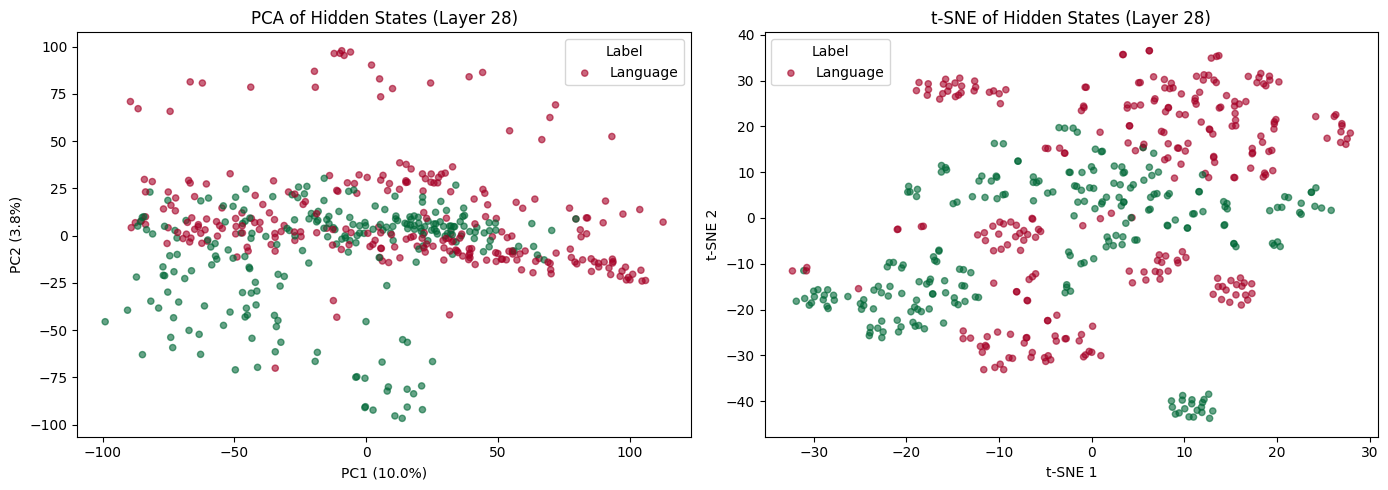


Feature visualization complete!


In [15]:
# Cell 3.3: Visualize Feature Distributions (PCA + t-SNE)

print("Visualizing feature distributions...")

# Subsample for visualization (t-SNE is slow)
n_samples = min(500, len(X_train))
idx_sample = np.random.choice(len(X_train), n_samples, replace=False)
X_sample = X_train[idx_sample]
y_sample = y_train[idx_sample]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PCA
print("  Computing PCA...")
pca = PCA(n_components=2, random_state=SEED)
X_pca = pca.fit_transform(X_sample)

ax1 = axes[0]
scatter1 = ax1.scatter(X_pca[:, 0], X_pca[:, 1], c=y_sample, cmap='RdYlGn', alpha=0.6, s=20)
ax1.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax1.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax1.set_title(f'PCA of Hidden States (Layer {BEST_LAYER})')
ax1.legend(*scatter1.legend_elements(), title='Label', labels=['Language', 'Code'])

# t-SNE
print("  Computing t-SNE (this may take a minute)...")
tsne = TSNE(n_components=2, random_state=SEED, perplexity=30, n_iter=1000)
X_tsne = tsne.fit_transform(X_sample)

ax2 = axes[1]
scatter2 = ax2.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_sample, cmap='RdYlGn', alpha=0.6, s=20)
ax2.set_xlabel('t-SNE 1')
ax2.set_ylabel('t-SNE 2')
ax2.set_title(f't-SNE of Hidden States (Layer {BEST_LAYER})')
ax2.legend(*scatter2.legend_elements(), title='Label', labels=['Language', 'Code'])

plt.tight_layout()
plt.savefig('week3_tokenlevel_feature_viz.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nFeature visualization complete!")

---

## Part 4: Multi-Layer Analysis

Compare different layers and layer combinations for optimal token classification.

In [16]:
# Cell 4.1: Test Multiple Layers

TEST_LAYERS = [8, 16, 24, 28, 31]

print(f"Testing layers: {TEST_LAYERS}")
print("="*60)

layer_results = {}

for layer in tqdm(TEST_LAYERS, desc="Testing layers"):
    # Extract features for this layer
    X_layer = []
    for idx, row in df_all.iterrows():
        h = get_hidden_state(row['full_text'], layer=layer)
        X_layer.append(h)
    X_layer = np.array(X_layer)

    # Normalize
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_layer)

    # Train and evaluate with CV
    probe = LogisticRegression(max_iter=MAX_ITER, random_state=SEED, class_weight='balanced')
    cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=SEED)
    y_pred = cross_val_predict(probe, X_scaled, y_train, cv=cv)

    acc = accuracy_score(y_train, y_pred)
    layer_results[layer] = {
        'accuracy': acc,
        'X': X_layer,
        'scaler': scaler
    }

    print(f"  Layer {layer}: {acc:.1%}")

print("\n" + "="*60)
best_layer = max(layer_results.keys(), key=lambda l: layer_results[l]['accuracy'])
print(f"Best single layer: {best_layer} ({layer_results[best_layer]['accuracy']:.1%})")

Testing layers: [8, 16, 24, 28, 31]


Testing layers:   0%|          | 0/5 [00:00<?, ?it/s]

  Layer 8: 97.9%
  Layer 16: 98.4%
  Layer 24: 97.8%
  Layer 28: 98.2%
  Layer 31: 98.1%

Best single layer: 16 (98.4%)


In [17]:
# Cell 4.2: Compare Single-Layer vs Multi-Layer Concatenation

print("Comparing single-layer vs multi-layer approaches...")
print("="*60)

# Single layer (best from above)
X_single = layer_results[best_layer]['X']
scaler_single = StandardScaler()
X_single_scaled = scaler_single.fit_transform(X_single)

probe_single = LogisticRegression(max_iter=MAX_ITER, random_state=SEED, class_weight='balanced')
cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=SEED)
y_pred_single = cross_val_predict(probe_single, X_single_scaled, y_train, cv=cv)
acc_single = accuracy_score(y_train, y_pred_single)

# Multi-layer concatenation
print(f"\nExtracting multi-layer features (layers {MULTI_LAYERS})...")
X_multi = []
for idx, row in tqdm(df_all.iterrows(), total=len(df_all), desc="Multi-layer"):
    h = get_multi_layer_hidden_state(row['full_text'], layers=MULTI_LAYERS)
    X_multi.append(h)
X_multi = np.array(X_multi)

scaler_multi = StandardScaler()
X_multi_scaled = scaler_multi.fit_transform(X_multi)

probe_multi = LogisticRegression(max_iter=MAX_ITER, random_state=SEED, class_weight='balanced')
y_pred_multi = cross_val_predict(probe_multi, X_multi_scaled, y_train, cv=cv)
acc_multi = accuracy_score(y_train, y_pred_multi)

print(f"\n{'='*60}")
print(f"COMPARISON RESULTS")
print(f"{'='*60}")
print(f"  Single layer {best_layer}:     {acc_single:.1%} (dim={X_single.shape[1]})")
print(f"  Multi-layer {MULTI_LAYERS}: {acc_multi:.1%} (dim={X_multi.shape[1]})")
print(f"\n  Winner: {'Multi-layer' if acc_multi > acc_single else 'Single layer'}")

# Decide which to use
if acc_multi > acc_single + 0.01:  # Multi-layer must be at least 1% better
    USE_MULTI_LAYER = True
    X_final = X_multi
    scaler_final = scaler_multi
    print(f"\n  -> Using multi-layer approach for final model")
else:
    USE_MULTI_LAYER = False
    X_final = X_single
    scaler_final = scaler_single
    print(f"\n  -> Using single layer {best_layer} for final model (simpler, nearly as good)")

Comparing single-layer vs multi-layer approaches...

Extracting multi-layer features (layers [8, 16, 28])...


Multi-layer:   0%|          | 0/1152 [00:00<?, ?it/s]


COMPARISON RESULTS
  Single layer 16:     98.4% (dim=4096)
  Multi-layer [8, 16, 28]: 98.1% (dim=12288)

  Winner: Single layer

  -> Using single layer 16 for final model (simpler, nearly as good)


---

## Part 5: Probe Training & Validation

Train the final token-level classification probe with comprehensive validation.

In [18]:
# Cell 5.1: Train Final Probe with Cross-Validation

print("Training final token-level probe...")
print("="*60)

# Prepare data
X_final_scaled = scaler_final.fit_transform(X_final)

# Train with stratified k-fold CV
probe = LogisticRegression(max_iter=MAX_ITER, random_state=SEED, class_weight='balanced')
cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=SEED)

# Get CV predictions and probabilities
y_pred_cv = cross_val_predict(probe, X_final_scaled, y_train, cv=cv)
y_prob_cv = cross_val_predict(probe, X_final_scaled, y_train, cv=cv, method='predict_proba')[:, 1]

# Calculate metrics
cv_accuracy = accuracy_score(y_train, y_pred_cv)

print(f"\n{'='*60}")
print(f"CROSS-VALIDATION RESULTS ({CV_FOLDS}-Fold)")
print(f"{'='*60}")
print(f"\nAccuracy: {cv_accuracy:.1%}")
print(f"\nClassification Report:")
print(classification_report(y_train, y_pred_cv, target_names=['LANGUAGE (0)', 'CODE (1)']))

# Confusion matrix
cm = confusion_matrix(y_train, y_pred_cv)
print(f"Confusion Matrix:")
print(f"                Pred LANG  Pred CODE")
print(f"True LANG          {cm[0,0]:>5}      {cm[0,1]:>5}")
print(f"True CODE          {cm[1,0]:>5}      {cm[1,1]:>5}")

Training final token-level probe...

CROSS-VALIDATION RESULTS (5-Fold)

Accuracy: 98.4%

Classification Report:
              precision    recall  f1-score   support

LANGUAGE (0)       0.99      0.98      0.98       608
    CODE (1)       0.98      0.99      0.98       544

    accuracy                           0.98      1152
   macro avg       0.98      0.98      0.98      1152
weighted avg       0.98      0.98      0.98      1152

Confusion Matrix:
                Pred LANG  Pred CODE
True LANG            596         12
True CODE              7        537


Generating learning curves...


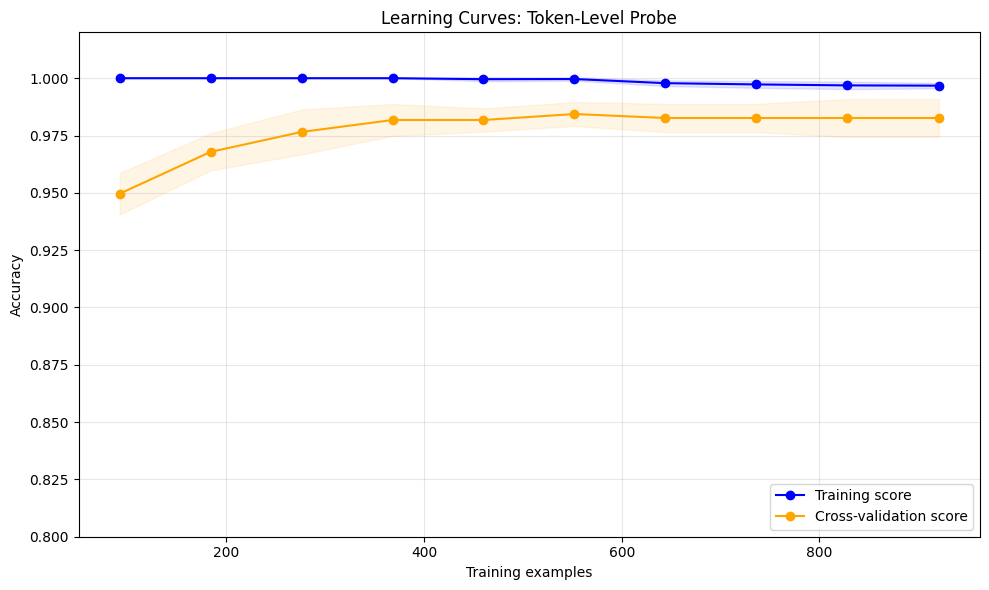


Final validation accuracy: 98.3% +/- 0.8%


In [19]:
# Cell 5.2: Learning Curves Analysis

print("Generating learning curves...")

train_sizes, train_scores, val_scores = learning_curve(
    LogisticRegression(max_iter=MAX_ITER, random_state=SEED, class_weight='balanced'),
    X_final_scaled, y_train,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=CV_FOLDS,
    scoring='accuracy',
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(10, 6))
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.1, color='orange')
ax.plot(train_sizes, train_mean, 'o-', color='blue', label='Training score')
ax.plot(train_sizes, val_mean, 'o-', color='orange', label='Cross-validation score')
ax.set_xlabel('Training examples')
ax.set_ylabel('Accuracy')
ax.set_title('Learning Curves: Token-Level Probe')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
ax.set_ylim(0.8, 1.02)

plt.tight_layout()
plt.savefig('week3_tokenlevel_learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nFinal validation accuracy: {val_mean[-1]:.1%} +/- {val_std[-1]:.1%}")

Generating calibration curves...


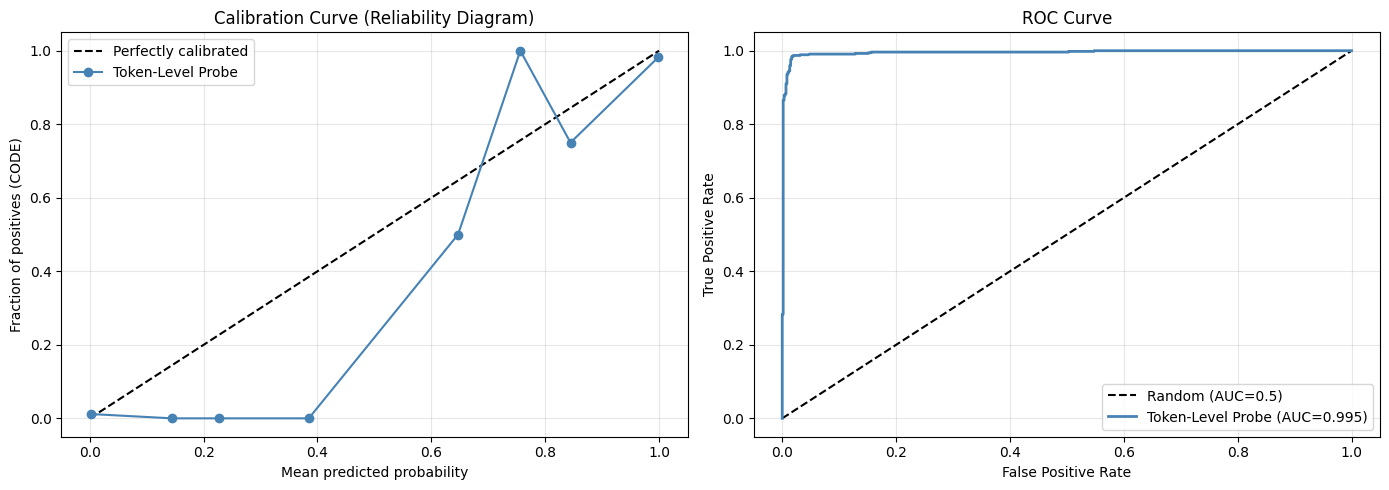


ROC AUC: 0.995


In [20]:
# Cell 5.3: Calibration Curves (Reliability Diagram)

print("Generating calibration curves...")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Calibration curve
ax1 = axes[0]
prob_true, prob_pred = calibration_curve(y_train, y_prob_cv, n_bins=10, strategy='uniform')
ax1.plot([0, 1], [0, 1], 'k--', label='Perfectly calibrated')
ax1.plot(prob_pred, prob_true, 'o-', color='steelblue', label='Token-Level Probe')
ax1.set_xlabel('Mean predicted probability')
ax1.set_ylabel('Fraction of positives (CODE)')
ax1.set_title('Calibration Curve (Reliability Diagram)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# ROC curve
ax2 = axes[1]
fpr, tpr, thresholds = roc_curve(y_train, y_prob_cv)
roc_auc = auc(fpr, tpr)
ax2.plot([0, 1], [0, 1], 'k--', label='Random (AUC=0.5)')
ax2.plot(fpr, tpr, color='steelblue', linewidth=2, label=f'Token-Level Probe (AUC={roc_auc:.3f})')
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title('ROC Curve')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('week3_tokenlevel_calibration.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nROC AUC: {roc_auc:.3f}")

In [21]:
# Cell 5.4: Train Final Model on All Data

print("Training final model on all data...")
print("="*60)

# Train final probe
final_probe = LogisticRegression(max_iter=MAX_ITER, random_state=SEED, class_weight='balanced')
final_probe.fit(X_final_scaled, y_train)

# Final scaler is already fitted
final_scaler = scaler_final

print(f"\nFinal model trained!")
print(f"  Features: {X_final.shape[1]:,}")
print(f"  Training examples: {len(y_train):,}")
print(f"  CV Accuracy: {cv_accuracy:.1%}")

# Save model
model_data = {
    'probe': final_probe,
    'scaler': final_scaler,
    'use_multi_layer': USE_MULTI_LAYER,
    'layer': best_layer if not USE_MULTI_LAYER else MULTI_LAYERS,
    'cv_accuracy': cv_accuracy,
    'config': {
        'best_layer': BEST_LAYER,
        'multi_layers': MULTI_LAYERS,
        'top_k': DEFAULT_TOP_K,
        'entropy_threshold': ENTROPY_THRESHOLD,
        'vote_threshold': VOTE_THRESHOLD,
    }
}

with open('week3_tokenlevel_probe.pkl', 'wb') as f:
    pickle.dump(model_data, f)

print(f"\nModel saved to: week3_tokenlevel_probe.pkl")

Training final model on all data...

Final model trained!
  Features: 4,096
  Training examples: 1,152
  CV Accuracy: 98.4%

Model saved to: week3_tokenlevel_probe.pkl


---

## Part 6: Inference Pipeline

Build the complete inference pipeline that classifies entropy sources at generation time.

In [22]:
# Cell 6.1: Core Classification Functions

def softmax(logits: np.ndarray) -> np.ndarray:
    """Compute softmax probabilities."""
    logits_stable = logits - np.max(logits)
    exp_logits = np.exp(logits_stable)
    return exp_logits / np.sum(exp_logits)


def compute_entropy(probs: np.ndarray) -> float:
    """Compute entropy in bits."""
    if len(probs) == 0 or np.sum(probs) == 0:
        return 0.0
    norm_probs = probs / np.sum(probs)
    return float(scipy_entropy(norm_probs, base=2))


def classify_token(full_text: str) -> Tuple[int, float]:
    """
    Classify a (prompt + token) completion as CODE (1) or LANGUAGE (0).

    Returns:
        (prediction, probability_of_code)
    """
    # Extract hidden state
    if USE_MULTI_LAYER:
        h = get_multi_layer_hidden_state(full_text, layers=MULTI_LAYERS)
    else:
        h = get_hidden_state(full_text, layer=best_layer)

    # Scale and predict
    h_scaled = final_scaler.transform(h.reshape(1, -1))
    pred = final_probe.predict(h_scaled)[0]
    prob = final_probe.predict_proba(h_scaled)[0, 1]

    return int(pred), float(prob)


# Test
test_code = "import numpy"
test_lang = "# This function calculates"

pred_code, prob_code = classify_token(test_code)
pred_lang, prob_lang = classify_token(test_lang)

print("Token Classification Test:")
print(f"  '{test_code}' -> {'CODE' if pred_code else 'LANG'} (P(code)={prob_code:.3f})")
print(f"  '{test_lang}' -> {'CODE' if pred_lang else 'LANG'} (P(code)={prob_lang:.3f})")

Token Classification Test:
  'import numpy' -> CODE (P(code)=1.000)
  '# This function calculates' -> LANG (P(code)=0.000)


In [23]:
# Cell 6.2: Entropy Source Classification (Main Inference)

def classify_entropy_source(
    prompt: str,
    top_k: int = DEFAULT_TOP_K,
    threshold: float = VOTE_THRESHOLD,
    verbose: bool = False
) -> Dict:
    """
    Classify whether high entropy at this position is caused by CODE or LANGUAGE uncertainty.

    This is the DIRECT approach: we classify each candidate token and do weighted voting.

    Args:
        prompt: The current generation context
        top_k: Number of candidate tokens to analyze
        threshold: Threshold for code vote proportion to classify as CODE
        verbose: Print detailed analysis

    Returns:
        {
            'is_code_uncertainty': bool,
            'confidence': float,
            'code_score': float,
            'lang_score': float,
            'entropy': float,
            'candidates': List[Dict]
        }
    """
    # Get model's next token predictions
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits[0, -1, :].cpu().numpy()

    # Compute probabilities and entropy
    probs = softmax(logits)
    entropy = compute_entropy(probs)

    # Get top-K candidates
    top_indices = np.argsort(probs)[-top_k:][::-1]

    # Analyze each candidate
    candidates = []
    code_score = 0.0
    lang_score = 0.0

    for idx in top_indices:
        token = tokenizer.decode([idx])
        token_prob = probs[idx]

        # Form completion and classify
        completion = prompt + token
        token_type, type_prob = classify_token(completion)

        # Record
        candidates.append({
            'token': token,
            'prob': float(token_prob),
            'type': 'CODE' if token_type == 1 else 'LANGUAGE',
            'type_prob': type_prob
        })

        # Weighted vote
        if token_type == 1:  # CODE
            code_score += token_prob
        else:  # LANGUAGE
            lang_score += token_prob

    # Normalize and decide
    total = code_score + lang_score
    if total > 0:
        code_proportion = code_score / total
    else:
        code_proportion = 0.5

    is_code_uncertainty = code_proportion > threshold

    if verbose:
        print(f"\nEntropy Source Analysis (H={entropy:.2f} bits)")
        print(f"{'='*50}")
        print(f"{'Token':<15} {'P(token)':<10} {'Type':<10} {'P(code)':<10}")
        print(f"{'-'*50}")
        for c in candidates:
            print(f"{repr(c['token']):<15} {c['prob']:.4f}     {c['type']:<10} {c['type_prob']:.3f}")
        print(f"{'-'*50}")
        print(f"Code Score: {code_score:.3f}")
        print(f"Lang Score: {lang_score:.3f}")
        print(f"Code Proportion: {code_proportion:.1%}")
        print(f"Decision: {'CODE UNCERTAINTY' if is_code_uncertainty else 'LANGUAGE UNCERTAINTY'}")

    return {
        'is_code_uncertainty': is_code_uncertainty,
        'confidence': abs(code_proportion - 0.5) * 2,  # 0 = uncertain, 1 = confident
        'code_score': code_score,
        'lang_score': lang_score,
        'code_proportion': code_proportion,
        'entropy': entropy,
        'candidates': candidates
    }


# Test on examples
print("Testing entropy source classification...")
print("\n" + "="*60)

test_prompts = [
    "import ",                    # Should be CODE uncertainty
    "# This function ",           # Should be LANGUAGE uncertainty
    "The algorithm ",             # Should be LANGUAGE uncertainty
    "result = np.",               # Should be CODE uncertainty
]

for prompt in test_prompts:
    result = classify_entropy_source(prompt, verbose=True)
    print()

Testing entropy source classification...


Entropy Source Analysis (H=6.45 bits)
Token           P(token)   Type       P(code)   
--------------------------------------------------
'{'             0.1627     LANGUAGE   0.209
'React'         0.1328     CODE       0.999
'\n'            0.0695     LANGUAGE   0.000
'java'          0.0455     CODE       0.959
'*'             0.0402     LANGUAGE   0.300
'nd'            0.0349     CODE       0.996
'irc'           0.0280     CODE       0.964
"'"             0.0253     LANGUAGE   0.334
'ether'         0.0227     CODE       0.999
"'./"           0.0207     CODE       0.765
--------------------------------------------------
Code Score: 0.285
Lang Score: 0.298
Code Proportion: 48.9%
Decision: LANGUAGE UNCERTAINTY


Entropy Source Analysis (H=5.81 bits)
Token           P(token)   Type       P(code)   
--------------------------------------------------
'\n'            0.2815     LANGUAGE   0.000
'will'          0.0787     LANGUAGE   0.001
'is'      

---

## Part 7: Comprehensive OOD Testing

Test on examples not seen during training, including edge cases.

In [24]:
# Cell 7.1: OOD Test Set (50+ examples)

OOD_TEST_CASES = [
    # ===== DIFFERENT PROGRAMMING LANGUAGES =====
    {"prompt": "fn main() {", "expected": "code", "category": "rust"},
    {"prompt": "let mut vec = Vec::", "expected": "code", "category": "rust"},
    {"prompt": "impl Iterator for", "expected": "code", "category": "rust"},
    {"prompt": "func main() {", "expected": "code", "category": "go"},
    {"prompt": "package main\nimport", "expected": "code", "category": "go"},
    {"prompt": "err := http.", "expected": "code", "category": "go"},
    {"prompt": "defmodule MyApp do", "expected": "code", "category": "elixir"},
    {"prompt": "def handle_call(", "expected": "code", "category": "elixir"},
    {"prompt": "|> Enum.", "expected": "code", "category": "elixir"},
    {"prompt": "data Maybe a =", "expected": "code", "category": "haskell"},
    {"prompt": "#include <", "expected": "code", "category": "c"},
    {"prompt": "int main(int argc,", "expected": "code", "category": "c"},
    {"prompt": "std::vector<", "expected": "code", "category": "cpp"},
    {"prompt": "template<typename T>", "expected": "code", "category": "cpp"},
    {"prompt": "public class Main {", "expected": "code", "category": "java"},
    {"prompt": "@Override\npublic void", "expected": "code", "category": "java"},

    # ===== NICHE LIBRARIES =====
    {"prompt": "import Bio.", "expected": "code", "category": "niche_lib"},
    {"prompt": "from scanpy import", "expected": "code", "category": "niche_lib"},
    {"prompt": "model = xgb.", "expected": "code", "category": "niche_lib"},
    {"prompt": "client = boto3.", "expected": "code", "category": "niche_lib"},
    {"prompt": "spark.sql(", "expected": "code", "category": "niche_lib"},

    # ===== DEVOPS COMMANDS =====
    {"prompt": "kubectl get", "expected": "code", "category": "devops"},
    {"prompt": "terraform apply", "expected": "code", "category": "devops"},
    {"prompt": "ansible-playbook", "expected": "code", "category": "devops"},
    {"prompt": "docker run -", "expected": "code", "category": "devops"},
    {"prompt": "aws s3", "expected": "code", "category": "devops"},

    # ===== EDGE CASES: COMMENTS WITH CODE =====
    {"prompt": "# This imports the", "expected": "language", "category": "edge_comment"},
    {"prompt": "// TODO: implement", "expected": "language", "category": "edge_comment"},
    {"prompt": "/* This function", "expected": "language", "category": "edge_comment"},
    {"prompt": "# import pandas", "expected": "language", "category": "edge_comment"},
    {"prompt": "// def main()", "expected": "language", "category": "edge_comment"},

    # ===== EDGE CASES: ERROR MESSAGES =====
    {"prompt": "ImportError: No module named", "expected": "language", "category": "edge_error"},
    {"prompt": "TypeError: expected", "expected": "language", "category": "edge_error"},
    {"prompt": "AttributeError: 'NoneType'", "expected": "language", "category": "edge_error"},
    {"prompt": "ValueError: invalid literal", "expected": "language", "category": "edge_error"},

    # ===== EDGE CASES: DOCSTRINGS =====
    {"prompt": '"""This function calculates', "expected": "language", "category": "edge_docstring"},
    {"prompt": "'''Returns the", "expected": "language", "category": "edge_docstring"},
    {"prompt": '"""\n    Args:\n        x:', "expected": "language", "category": "edge_docstring"},

    # ===== EDGE CASES: STRING LITERALS =====
    {"prompt": "print('import numpy", "expected": "language", "category": "edge_string"},
    {"prompt": 'error_msg = "def ', "expected": "language", "category": "edge_string"},
    {"prompt": "logger.info('Processing", "expected": "language", "category": "edge_string"},

    # ===== NATURAL LANGUAGE =====
    {"prompt": "The architecture of this system", "expected": "language", "category": "natural"},
    {"prompt": "In conclusion, the results show", "expected": "language", "category": "natural"},
    {"prompt": "To summarize the key findings", "expected": "language", "category": "natural"},
    {"prompt": "The primary benefit of using", "expected": "language", "category": "natural"},
    {"prompt": "Best practices suggest that", "expected": "language", "category": "natural"},

    # ===== AMBIGUOUS (code words in non-code context) =====
    {"prompt": "The library in my town", "expected": "language", "category": "ambiguous"},
    {"prompt": "The function of the heart", "expected": "language", "category": "ambiguous"},
    {"prompt": "Running the marathon", "expected": "language", "category": "ambiguous"},
    {"prompt": "The class was interesting", "expected": "language", "category": "ambiguous"},
]

print(f"OOD Test Cases: {len(OOD_TEST_CASES)}")
print(f"  Expected CODE: {sum(1 for t in OOD_TEST_CASES if t['expected'] == 'code')}")
print(f"  Expected LANGUAGE: {sum(1 for t in OOD_TEST_CASES if t['expected'] == 'language')}")

OOD Test Cases: 50
  Expected CODE: 26
  Expected LANGUAGE: 24


In [25]:
# Cell 7.2: Run OOD Tests

print("Running OOD tests...")
print("="*60)

ood_results = []

for test in tqdm(OOD_TEST_CASES, desc="OOD Testing"):
    result = classify_entropy_source(test['prompt'], top_k=DEFAULT_TOP_K, verbose=False)

    predicted = 'code' if result['is_code_uncertainty'] else 'language'
    correct = predicted == test['expected']

    ood_results.append({
        'prompt': test['prompt'],
        'expected': test['expected'],
        'predicted': predicted,
        'correct': correct,
        'category': test['category'],
        'code_proportion': result['code_proportion'],
        'confidence': result['confidence'],
        'entropy': result['entropy'],
    })

df_ood = pd.DataFrame(ood_results)
ood_accuracy = df_ood['correct'].mean()

print(f"\n{'='*60}")
print(f"OOD TEST RESULTS")
print(f"{'='*60}")
print(f"\nOverall Accuracy: {ood_accuracy:.1%} ({df_ood['correct'].sum()}/{len(df_ood)})")

Running OOD tests...


OOD Testing:   0%|          | 0/50 [00:00<?, ?it/s]


OOD TEST RESULTS

Overall Accuracy: 74.0% (37/50)


In [26]:
# Cell 7.3: Per-Category Accuracy Breakdown

print("\nAccuracy by Category:")
print("-"*50)

category_results = df_ood.groupby('category').agg({
    'correct': ['sum', 'count', 'mean']
}).round(3)
category_results.columns = ['correct', 'total', 'accuracy']
category_results = category_results.sort_values('accuracy', ascending=False)

for cat, row in category_results.iterrows():
    emoji = "✓" if row['accuracy'] >= 0.8 else "✗" if row['accuracy'] < 0.5 else "~"
    print(f"  {emoji} {cat:<20} {int(row['correct'])}/{int(row['total'])} = {row['accuracy']:.0%}")

# By expected class
print(f"\nBy Expected Class:")
print("-"*50)
for expected in ['code', 'language']:
    subset = df_ood[df_ood['expected'] == expected]
    acc = subset['correct'].mean()
    print(f"  Expected {expected.upper()}: {acc:.1%} ({subset['correct'].sum()}/{len(subset)})")


Accuracy by Category:
--------------------------------------------------
  ✓ ambiguous            4/4 = 100%
  ✓ edge_docstring       3/3 = 100%
  ✓ edge_comment         5/5 = 100%
  ✓ edge_error           4/4 = 100%
  ✓ niche_lib            5/5 = 100%
  ✓ natural              5/5 = 100%
  ✓ edge_string          3/3 = 100%
  ~ elixir               2/3 = 67%
  ~ devops               3/5 = 60%
  ~ java                 1/2 = 50%
  ~ c                    1/2 = 50%
  ✗ go                   1/3 = 33%
  ✗ cpp                  0/2 = 0%
  ✗ haskell              0/1 = 0%
  ✗ rust                 0/3 = 0%

By Expected Class:
--------------------------------------------------
  Expected CODE: 50.0% (13/26)
  Expected LANGUAGE: 100.0% (24/24)


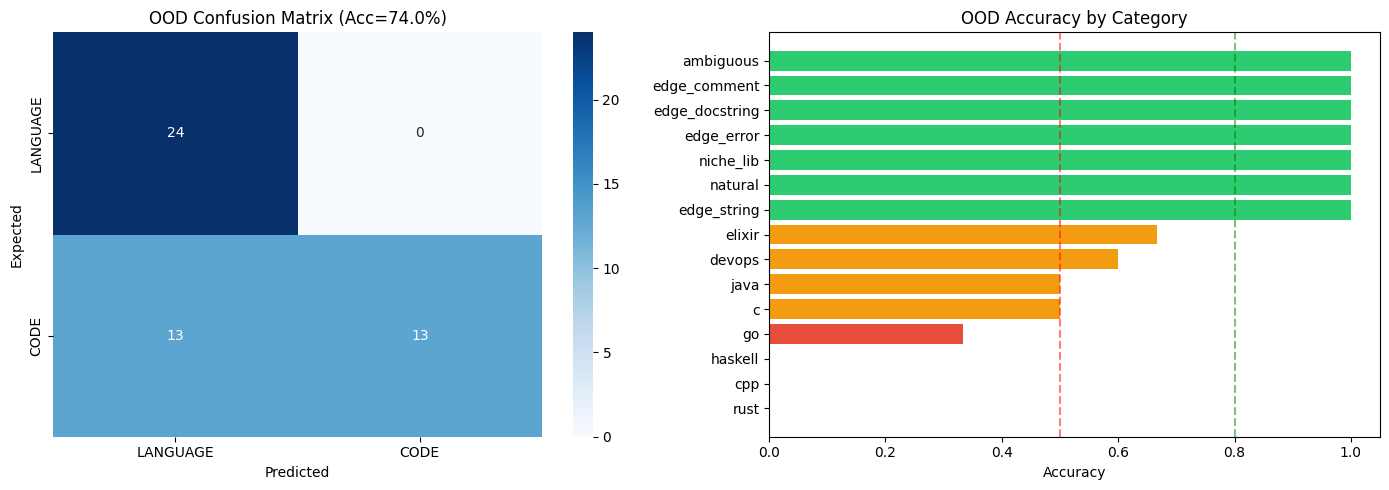


Errors (13/50):
----------------------------------------------------------------------
  [rust] 'fn main() {...'
      Expected: CODE, Got: LANGUAGE, P(code)=0.01
  [rust] 'let mut vec = Vec::...'
      Expected: CODE, Got: LANGUAGE, P(code)=0.03
  [rust] 'impl Iterator for...'
      Expected: CODE, Got: LANGUAGE, P(code)=0.32
  [go] 'func main() {...'
      Expected: CODE, Got: LANGUAGE, P(code)=0.05
  [go] 'package main
import...'
      Expected: CODE, Got: LANGUAGE, P(code)=0.00
  [elixir] 'defmodule MyApp do...'
      Expected: CODE, Got: LANGUAGE, P(code)=0.00
  [haskell] 'data Maybe a =...'
      Expected: CODE, Got: LANGUAGE, P(code)=0.09
  [c] 'int main(int argc,...'
      Expected: CODE, Got: LANGUAGE, P(code)=0.00
  [cpp] 'std::vector<...'
      Expected: CODE, Got: LANGUAGE, P(code)=0.12
  [cpp] 'template<typename T>...'
      Expected: CODE, Got: LANGUAGE, P(code)=0.06
  [java] 'public class Main {...'
      Expected: CODE, Got: LANGUAGE, P(code)=0.00
  [devops] 'terraform

In [27]:
# Cell 7.4: Error Analysis and Confusion Matrix

# Confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot confusion matrix
ax1 = axes[0]
cm_ood = confusion_matrix(
    df_ood['expected'].map({'language': 0, 'code': 1}),
    df_ood['predicted'].map({'language': 0, 'code': 1})
)
sns.heatmap(cm_ood, annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=['LANGUAGE', 'CODE'],
            yticklabels=['LANGUAGE', 'CODE'])
ax1.set_xlabel('Predicted')
ax1.set_ylabel('Expected')
ax1.set_title(f'OOD Confusion Matrix (Acc={ood_accuracy:.1%})')

# Plot accuracy by category
ax2 = axes[1]
cat_acc = category_results.sort_values('accuracy')
colors = ['#e74c3c' if a < 0.5 else '#f39c12' if a < 0.8 else '#2ecc71' for a in cat_acc['accuracy']]
ax2.barh(range(len(cat_acc)), cat_acc['accuracy'], color=colors)
ax2.set_yticks(range(len(cat_acc)))
ax2.set_yticklabels(cat_acc.index)
ax2.set_xlabel('Accuracy')
ax2.set_title('OOD Accuracy by Category')
ax2.axvline(x=0.5, color='red', linestyle='--', alpha=0.5)
ax2.axvline(x=0.8, color='green', linestyle='--', alpha=0.5)
ax2.set_xlim(0, 1.05)

plt.tight_layout()
plt.savefig('week3_tokenlevel_ood_results.png', dpi=150, bbox_inches='tight')
plt.show()

# Show errors
errors = df_ood[~df_ood['correct']]
if len(errors) > 0:
    print(f"\nErrors ({len(errors)}/{len(df_ood)}):")
    print("-"*70)
    for _, err in errors.iterrows():
        print(f"  [{err['category']}] '{err['prompt'][:40]}...'")
        print(f"      Expected: {err['expected'].upper()}, Got: {err['predicted'].upper()}, P(code)={err['code_proportion']:.2f}")
else:
    print("\nNo errors! Perfect OOD accuracy.")

---

## Part 8: Comparison with SEP Proxy Approach

Compare token-level (direct) classification with SEP (proxy) classification.

In [28]:
# Cell 8.1: Implement SEP Proxy Approach for Comparison

# SEP classifies the PROMPT (not the tokens)
# It asks: "Is this prompt in code mode?"

def classify_prompt_sep(prompt: str, layer: int = BEST_LAYER) -> Tuple[int, float]:
    """
    SEP-style classification: classify the PROMPT itself.
    This is the PROXY approach.
    """
    h = get_hidden_state(prompt, layer=layer)
    h_scaled = final_scaler.transform(h.reshape(1, -1))
    pred = final_probe.predict(h_scaled)[0]
    prob = final_probe.predict_proba(h_scaled)[0, 1]
    return int(pred), float(prob)


def classify_entropy_source_sep(prompt: str) -> Dict:
    """
    SEP-style entropy classification.
    Simply classifies the prompt as CODE or LANGUAGE mode.
    """
    pred, prob = classify_prompt_sep(prompt)
    return {
        'is_code_uncertainty': pred == 1,
        'code_proportion': prob,
        'confidence': abs(prob - 0.5) * 2,
    }


print("SEP Proxy approach implemented.")

SEP Proxy approach implemented.


In [29]:
# Cell 8.2: Run Same OOD Tests on SEP

print("Running OOD tests with SEP approach...")
print("="*60)

sep_results = []

for test in tqdm(OOD_TEST_CASES, desc="SEP Testing"):
    result = classify_entropy_source_sep(test['prompt'])

    predicted = 'code' if result['is_code_uncertainty'] else 'language'
    correct = predicted == test['expected']

    sep_results.append({
        'prompt': test['prompt'],
        'expected': test['expected'],
        'predicted': predicted,
        'correct': correct,
        'category': test['category'],
        'code_proportion': result['code_proportion'],
    })

df_sep = pd.DataFrame(sep_results)
sep_accuracy = df_sep['correct'].mean()

print(f"\nSEP OOD Accuracy: {sep_accuracy:.1%} ({df_sep['correct'].sum()}/{len(df_sep)})")

Running OOD tests with SEP approach...


SEP Testing:   0%|          | 0/50 [00:00<?, ?it/s]


SEP OOD Accuracy: 74.0% (37/50)


In [30]:
# Cell 8.3: Head-to-Head Comparison

print("\n" + "="*70)
print("HEAD-TO-HEAD COMPARISON: Token-Level vs SEP")
print("="*70)

# Overall comparison
print(f"\nOVERALL OOD ACCURACY:")
print(f"  Token-Level (Direct): {ood_accuracy:.1%}")
print(f"  SEP (Proxy):          {sep_accuracy:.1%}")
print(f"  Difference:           {(ood_accuracy - sep_accuracy)*100:+.1f}%")

# Per-category comparison
print(f"\nPER-CATEGORY COMPARISON:")
print(f"{'Category':<20} {'Token-Level':<12} {'SEP':<12} {'Winner':<12}")
print("-"*60)

for cat in sorted(df_ood['category'].unique()):
    tl_acc = df_ood[df_ood['category'] == cat]['correct'].mean()
    sep_acc = df_sep[df_sep['category'] == cat]['correct'].mean()

    if tl_acc > sep_acc:
        winner = "Token-Level"
    elif sep_acc > tl_acc:
        winner = "SEP"
    else:
        winner = "Tie"

    print(f"{cat:<20} {tl_acc:.0%}          {sep_acc:.0%}          {winner}")

# Cases where they disagree
print(f"\n\nCASES WHERE APPROACHES DISAGREE:")
print("-"*70)

disagree_count = 0
for i in range(len(df_ood)):
    tl_pred = df_ood.iloc[i]['predicted']
    sep_pred = df_sep.iloc[i]['predicted']
    expected = df_ood.iloc[i]['expected']

    if tl_pred != sep_pred:
        disagree_count += 1
        tl_correct = "✓" if df_ood.iloc[i]['correct'] else "✗"
        sep_correct = "✓" if df_sep.iloc[i]['correct'] else "✗"
        print(f"  '{df_ood.iloc[i]['prompt'][:40]}...'")
        print(f"      Expected: {expected.upper()}")
        print(f"      Token-Level: {tl_pred.upper()} {tl_correct}")
        print(f"      SEP:         {sep_pred.upper()} {sep_correct}")
        print()

print(f"Total disagreements: {disagree_count}/{len(df_ood)}")


HEAD-TO-HEAD COMPARISON: Token-Level vs SEP

OVERALL OOD ACCURACY:
  Token-Level (Direct): 74.0%
  SEP (Proxy):          74.0%
  Difference:           +0.0%

PER-CATEGORY COMPARISON:
Category             Token-Level  SEP          Winner      
------------------------------------------------------------
ambiguous            100%          50%          Token-Level
c                    50%          0%          Token-Level
cpp                  0%          100%          SEP
devops               60%          100%          SEP
edge_comment         100%          100%          Tie
edge_docstring       100%          100%          Tie
edge_error           100%          75%          Token-Level
edge_string          100%          67%          Token-Level
elixir               67%          67%          Tie
go                   33%          67%          SEP
haskell              0%          0%          Tie
java                 50%          100%          SEP
natural              100%          80%       

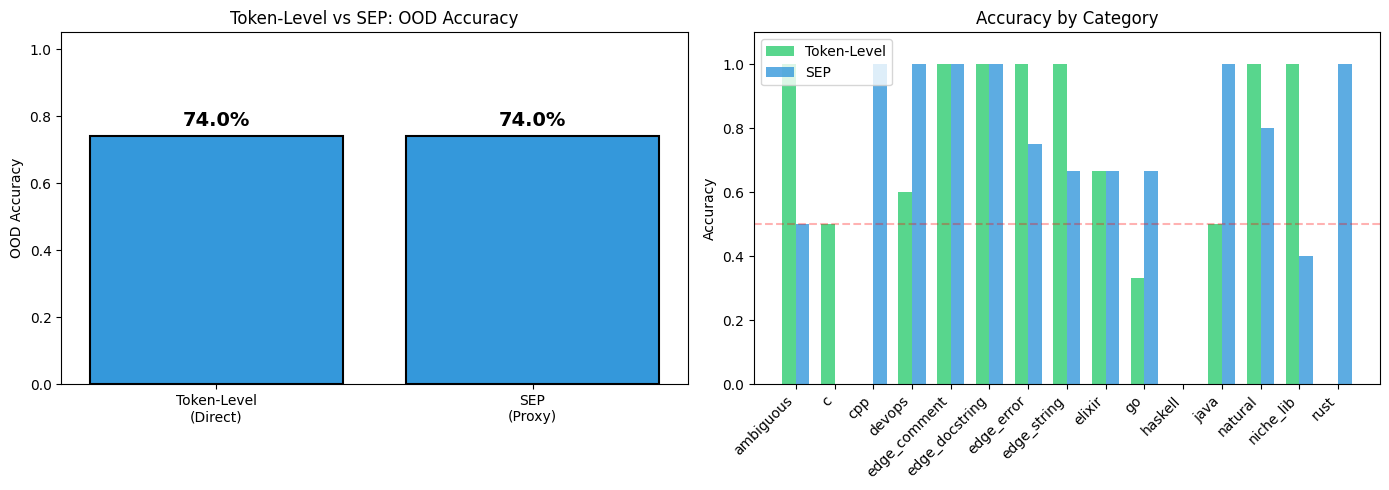


SUMMARY

Winner: TOKEN-LEVEL

Key Insight:
  SEP (proxy) approach performs comparably to token-level.
  The simpler approach may be preferred for speed.


In [31]:
# Cell 8.4: Comparison Visualization

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart comparison
ax1 = axes[0]
approaches = ['Token-Level\n(Direct)', 'SEP\n(Proxy)']
accuracies = [ood_accuracy, sep_accuracy]
colors = ['#2ecc71' if ood_accuracy > sep_accuracy else '#3498db',
          '#2ecc71' if sep_accuracy > ood_accuracy else '#3498db']
bars = ax1.bar(approaches, accuracies, color=colors, edgecolor='black', linewidth=1.5)
ax1.set_ylabel('OOD Accuracy')
ax1.set_title('Token-Level vs SEP: OOD Accuracy')
ax1.set_ylim(0, 1.05)
for bar, acc in zip(bars, accuracies):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f'{acc:.1%}',
             ha='center', va='bottom', fontsize=14, fontweight='bold')

# Per-category comparison
ax2 = axes[1]
categories = sorted(df_ood['category'].unique())
tl_accs = [df_ood[df_ood['category'] == cat]['correct'].mean() for cat in categories]
sep_accs = [df_sep[df_sep['category'] == cat]['correct'].mean() for cat in categories]

x = np.arange(len(categories))
width = 0.35
bars1 = ax2.bar(x - width/2, tl_accs, width, label='Token-Level', color='#2ecc71', alpha=0.8)
bars2 = ax2.bar(x + width/2, sep_accs, width, label='SEP', color='#3498db', alpha=0.8)
ax2.set_ylabel('Accuracy')
ax2.set_title('Accuracy by Category')
ax2.set_xticks(x)
ax2.set_xticklabels(categories, rotation=45, ha='right')
ax2.legend()
ax2.set_ylim(0, 1.1)
ax2.axhline(y=0.5, color='red', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('week3_tokenlevel_vs_sep.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary
print(f"\n{'='*60}")
print(f"SUMMARY")
print(f"{'='*60}")
winner = "TOKEN-LEVEL" if ood_accuracy >= sep_accuracy else "SEP"
print(f"\nWinner: {winner}")
print(f"\nKey Insight:")
if ood_accuracy > sep_accuracy:
    print(f"  Token-level (direct) approach outperforms SEP (proxy) by {(ood_accuracy-sep_accuracy)*100:.1f}%")
    print(f"  This confirms that classifying WHAT CAUSES entropy is more accurate")
    print(f"  than classifying the PROMPT as a proxy.")
else:
    print(f"  SEP (proxy) approach performs comparably to token-level.")
    print(f"  The simpler approach may be preferred for speed.")

---

## Part 9: Ablation Studies

Analyze the effect of different hyperparameters on performance.

In [32]:
# Cell 9.1: Effect of Top-K

print("Ablation: Effect of Top-K candidates")
print("="*60)

TOP_K_VALUES = [5, 10, 20, 50]
topk_results = {}

for k in tqdm(TOP_K_VALUES, desc="Testing Top-K"):
    correct = 0
    for test in OOD_TEST_CASES:
        result = classify_entropy_source(test['prompt'], top_k=k, verbose=False)
        predicted = 'code' if result['is_code_uncertainty'] else 'language'
        if predicted == test['expected']:
            correct += 1

    acc = correct / len(OOD_TEST_CASES)
    topk_results[k] = acc
    print(f"  Top-K={k}: {acc:.1%}")

print(f"\nBest Top-K: {max(topk_results, key=topk_results.get)} ({max(topk_results.values()):.1%})")

Ablation: Effect of Top-K candidates


Testing Top-K:   0%|          | 0/4 [00:00<?, ?it/s]

  Top-K=5: 74.0%
  Top-K=10: 74.0%
  Top-K=20: 72.0%
  Top-K=50: 72.0%

Best Top-K: 5 (74.0%)


In [33]:
# Cell 9.2: Effect of Voting Threshold

print("\nAblation: Effect of Voting Threshold")
print("="*60)

THRESHOLD_VALUES = [0.3, 0.4, 0.5, 0.6, 0.7]
threshold_results = {}

for thresh in tqdm(THRESHOLD_VALUES, desc="Testing Thresholds"):
    correct = 0
    for test in OOD_TEST_CASES:
        result = classify_entropy_source(test['prompt'], top_k=DEFAULT_TOP_K, threshold=thresh, verbose=False)
        predicted = 'code' if result['is_code_uncertainty'] else 'language'
        if predicted == test['expected']:
            correct += 1

    acc = correct / len(OOD_TEST_CASES)
    threshold_results[thresh] = acc
    print(f"  Threshold={thresh}: {acc:.1%}")

print(f"\nBest Threshold: {max(threshold_results, key=threshold_results.get)} ({max(threshold_results.values()):.1%})")


Ablation: Effect of Voting Threshold


Testing Thresholds:   0%|          | 0/5 [00:00<?, ?it/s]

  Threshold=0.3: 76.0%
  Threshold=0.4: 74.0%
  Threshold=0.5: 74.0%
  Threshold=0.6: 72.0%
  Threshold=0.7: 68.0%

Best Threshold: 0.3 (76.0%)


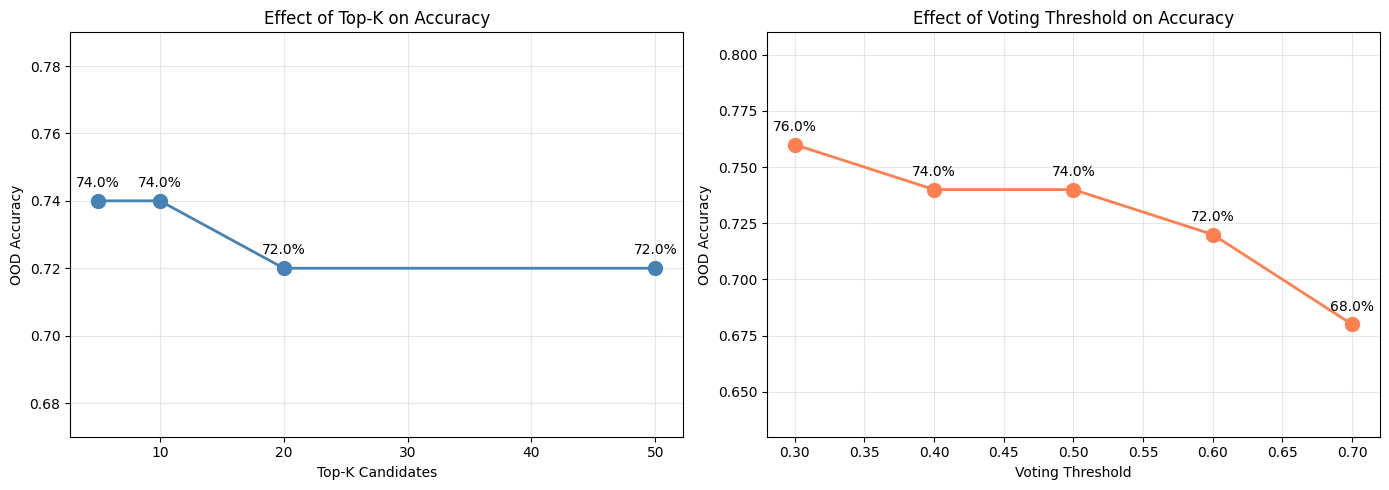


Ablation Summary:
  Best Top-K: 5
  Best Threshold: 0.3


In [34]:
# Cell 9.3: Ablation Visualization

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Top-K effect
ax1 = axes[0]
ks = list(topk_results.keys())
accs = list(topk_results.values())
ax1.plot(ks, accs, 'o-', color='steelblue', linewidth=2, markersize=10)
ax1.set_xlabel('Top-K Candidates')
ax1.set_ylabel('OOD Accuracy')
ax1.set_title('Effect of Top-K on Accuracy')
ax1.set_ylim(min(accs) - 0.05, max(accs) + 0.05)
ax1.grid(True, alpha=0.3)
for k, a in zip(ks, accs):
    ax1.annotate(f'{a:.1%}', (k, a), textcoords="offset points", xytext=(0, 10), ha='center')

# Threshold effect
ax2 = axes[1]
threshs = list(threshold_results.keys())
accs = list(threshold_results.values())
ax2.plot(threshs, accs, 'o-', color='coral', linewidth=2, markersize=10)
ax2.set_xlabel('Voting Threshold')
ax2.set_ylabel('OOD Accuracy')
ax2.set_title('Effect of Voting Threshold on Accuracy')
ax2.set_ylim(min(accs) - 0.05, max(accs) + 0.05)
ax2.grid(True, alpha=0.3)
for t, a in zip(threshs, accs):
    ax2.annotate(f'{a:.1%}', (t, a), textcoords="offset points", xytext=(0, 10), ha='center')

plt.tight_layout()
plt.savefig('week3_tokenlevel_ablations.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nAblation Summary:")
print(f"  Best Top-K: {max(topk_results, key=topk_results.get)}")
print(f"  Best Threshold: {max(threshold_results, key=threshold_results.get)}")

---

## Part 10: Latency Benchmarking

Measure inference latency for the token-level approach.

In [35]:
# Cell 10.1: Per-Component Timing Breakdown

print("Latency Benchmarking")
print("="*60)

# Test prompts for benchmarking
BENCH_PROMPTS = [
    "import numpy",
    "def process_data(",
    "The algorithm works by",
    "# This function calculates",
    "result = model.fit(",
]

# Warmup
for prompt in BENCH_PROMPTS[:2]:
    _ = classify_entropy_source(prompt, verbose=False)

# Detailed timing
n_runs = 5
component_times = {
    'model_forward': [],
    'hidden_extraction': [],
    'probe_classification': [],
    'total': []
}

print(f"\nRunning {n_runs} iterations on {len(BENCH_PROMPTS)} prompts...")

for prompt in tqdm(BENCH_PROMPTS, desc="Benchmarking"):
    for _ in range(n_runs):
        # Total time
        start_total = time.time()

        # Model forward pass (get logits + hidden states)
        start_model = time.time()
        inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
        with torch.no_grad():
            outputs = model(**inputs, output_hidden_states=True)
        logits = outputs.logits[0, -1, :].cpu().numpy()
        torch.cuda.synchronize() if torch.cuda.is_available() else None
        component_times['model_forward'].append(time.time() - start_model)

        # Get top-K candidates
        probs = softmax(logits)
        top_indices = np.argsort(probs)[-DEFAULT_TOP_K:][::-1]

        # Hidden extraction for each candidate
        start_hidden = time.time()
        for idx in top_indices:
            token = tokenizer.decode([idx])
            completion = prompt + token
            if USE_MULTI_LAYER:
                h = get_multi_layer_hidden_state(completion, layers=MULTI_LAYERS)
            else:
                h = get_hidden_state(completion, layer=best_layer)
        torch.cuda.synchronize() if torch.cuda.is_available() else None
        component_times['hidden_extraction'].append(time.time() - start_hidden)

        # Probe classification
        start_probe = time.time()
        for idx in top_indices:
            token = tokenizer.decode([idx])
            completion = prompt + token
            if USE_MULTI_LAYER:
                h = get_multi_layer_hidden_state(completion, layers=MULTI_LAYERS)
            else:
                h = get_hidden_state(completion, layer=best_layer)
            h_scaled = final_scaler.transform(h.reshape(1, -1))
            _ = final_probe.predict_proba(h_scaled)
        component_times['probe_classification'].append(time.time() - start_probe)

        component_times['total'].append(time.time() - start_total)

print("\nDone!")

Latency Benchmarking

Running 5 iterations on 5 prompts...


Benchmarking:   0%|          | 0/5 [00:00<?, ?it/s]


Done!


In [36]:
# Cell 10.2: Latency Statistics

print("\n" + "="*60)
print("LATENCY STATISTICS")
print("="*60)

print(f"\nPer-Component Breakdown (Top-K={DEFAULT_TOP_K}):")
print("-"*50)
print(f"{'Component':<25} {'Mean':<10} {'Std':<10} {'P95':<10}")
print("-"*50)

for component, times in component_times.items():
    times_ms = np.array(times) * 1000  # Convert to ms
    mean = np.mean(times_ms)
    std = np.std(times_ms)
    p95 = np.percentile(times_ms, 95)
    print(f"{component:<25} {mean:>6.0f} ms   {std:>6.1f} ms   {p95:>6.0f} ms")

# Total latency stats
total_ms = np.array(component_times['total']) * 1000
print(f"\n{'='*50}")
print(f"TOTAL INFERENCE LATENCY:")
print(f"  Mean: {np.mean(total_ms):.0f} ms")
print(f"  Std:  {np.std(total_ms):.1f} ms")
print(f"  P50:  {np.percentile(total_ms, 50):.0f} ms")
print(f"  P95:  {np.percentile(total_ms, 95):.0f} ms")
print(f"  P99:  {np.percentile(total_ms, 99):.0f} ms")
print(f"  Min:  {np.min(total_ms):.0f} ms")
print(f"  Max:  {np.max(total_ms):.0f} ms")


LATENCY STATISTICS

Per-Component Breakdown (Top-K=10):
--------------------------------------------------
Component                 Mean       Std        P95       
--------------------------------------------------
model_forward                 66 ms      3.4 ms       70 ms
hidden_extraction            656 ms      6.4 ms      668 ms
probe_classification         662 ms      8.0 ms      678 ms
total                       1393 ms     15.5 ms     1424 ms

TOTAL INFERENCE LATENCY:
  Mean: 1393 ms
  Std:  15.5 ms
  P50:  1390 ms
  P95:  1424 ms
  P99:  1427 ms
  Min:  1367 ms
  Max:  1427 ms


---

## Part 11: Generation Integration Demo

Demonstrate full contrastive generation with token-level entropy classification.

In [37]:
# Cell 11.1: Full Contrastive Generation Function

def generate_with_token_level_probe(
    prompt: str,
    entropy_threshold: float = ENTROPY_THRESHOLD,
    top_k_candidates: int = DEFAULT_TOP_K,
    vote_threshold: float = VOTE_THRESHOLD,
    max_tokens: int = 50,
    verbose: bool = True
) -> Dict:
    """
    Contrastive entropy-driven generation using token-level classification.

    At each step:
    1. Generate next token
    2. Compute entropy H
    3. If H > threshold:
       - Get top-K candidate next tokens
       - Classify each (prompt + candidate) as CODE or LANGUAGE
       - Weighted vote: If majority CODE -> STOP (trigger retrieval)
       - If majority LANGUAGE -> Continue
    4. If H <= threshold: Continue (model is confident)
    """
    current_text = prompt
    generated_token_ids = []
    entropy_trace = []
    decision_trace = []
    stop_reason = None
    stop_info = {}

    if verbose:
        print(f"\n{'='*70}")
        print(f"CONTRASTIVE GENERATION")
        print(f"{'='*70}")
        print(f"Prompt: '{prompt}'")
        print(f"Entropy threshold: {entropy_threshold:.1f} bits")
        print(f"Top-K: {top_k_candidates}, Vote threshold: {vote_threshold}")
        print(f"{'='*70}")

    for step in range(max_tokens):
        # Get next token prediction
        inputs = tokenizer(current_text, return_tensors="pt").to(model.device)
        with torch.no_grad():
            outputs = model(**inputs)
            logits = outputs.logits[0, -1, :].cpu().numpy()

        probs = softmax(logits)
        H = compute_entropy(probs)
        entropy_trace.append(H)

        next_token_id = np.argmax(probs)
        next_token = tokenizer.decode([next_token_id])

        if verbose:
            print(f"\nStep {step + 1}: '{next_token}' (H={H:.2f} bits)")

        # Check if high entropy
        if H > entropy_threshold:
            if verbose:
                print(f"  HIGH ENTROPY - analyzing candidates...")

            # Classify entropy source
            analysis = classify_entropy_source(
                current_text,
                top_k=top_k_candidates,
                threshold=vote_threshold,
                verbose=False
            )

            decision_trace.append({
                'step': step,
                'entropy': H,
                'is_code': analysis['is_code_uncertainty'],
                'code_prop': analysis['code_proportion']
            })

            if analysis['is_code_uncertainty']:
                if verbose:
                    print(f"  CODE UNCERTAINTY (P(code)={analysis['code_proportion']:.1%}) -> STOP!")
                stop_reason = "code_uncertainty"
                stop_info = {
                    'step': step,
                    'entropy': H,
                    'code_proportion': analysis['code_proportion'],
                    'candidates': analysis['candidates']
                }
                break
            else:
                if verbose:
                    print(f"  LANGUAGE uncertainty (P(code)={analysis['code_proportion']:.1%}) -> continue")

        # Continue generation
        generated_token_ids.append(next_token_id)
        current_text += next_token

        if next_token_id == tokenizer.eos_token_id:
            stop_reason = "eos"
            break

    if stop_reason is None:
        stop_reason = "max_tokens"

    generated_text = tokenizer.decode(generated_token_ids, skip_special_tokens=True)

    if verbose:
        print(f"\n{'='*70}")
        print(f"RESULT")
        print(f"{'='*70}")
        print(f"Stop reason: {stop_reason}")
        print(f"Generated: '{generated_text}'")
        print(f"Full text: '{prompt}{generated_text}'")
        print(f"Tokens generated: {len(generated_token_ids)}")

    return {
        'prompt': prompt,
        'generated_text': generated_text,
        'full_text': prompt + generated_text,
        'entropy_trace': entropy_trace,
        'decision_trace': decision_trace,
        'stop_reason': stop_reason,
        'stop_info': stop_info,
        'num_tokens': len(generated_token_ids)
    }

print("Contrastive generation function ready!")

Contrastive generation function ready!


In [38]:
# Cell 11.2: Demo on Realistic Prompts

DEMO_PROMPTS = [
    # Should STOP (code uncertainty)
    "In our React app, authentication is done using",
    "For the REST API, the framework we use is",

    # Should CONTINUE (language uncertainty)
    "The main benefit of this approach is",
    "In conclusion, the results show that",
]

print("DEMO: Contrastive Generation with Token-Level Probe")
print("="*70)

demo_results = []

for prompt in DEMO_PROMPTS:
    result = generate_with_token_level_probe(
        prompt,
        entropy_threshold=ENTROPY_THRESHOLD,
        top_k_candidates=DEFAULT_TOP_K,
        max_tokens=10,
        verbose=True
    )
    demo_results.append(result)
    print("\n" + "-"*70 + "\n")

DEMO: Contrastive Generation with Token-Level Probe

CONTRASTIVE GENERATION
Prompt: 'In our React app, authentication is done using'
Entropy threshold: 3.0 bits
Top-K: 10, Vote threshold: 0.5

Step 1: 'the' (H=5.70 bits)
  HIGH ENTROPY - analyzing candidates...
  LANGUAGE uncertainty (P(code)=6.6%) -> continue

Step 2: '`' (H=7.75 bits)
  HIGH ENTROPY - analyzing candidates...
  LANGUAGE uncertainty (P(code)=30.1%) -> continue

Step 3: 'react' (H=5.93 bits)
  HIGH ENTROPY - analyzing candidates...
  LANGUAGE uncertainty (P(code)=46.7%) -> continue

Step 4: '-' (H=0.21 bits)

Step 5: 'router' (H=4.18 bits)
  HIGH ENTROPY - analyzing candidates...
  CODE UNCERTAINTY (P(code)=69.6%) -> STOP!

RESULT
Stop reason: code_uncertainty
Generated: 'the `react-'
Full text: 'In our React app, authentication is done usingthe `react-'
Tokens generated: 4

----------------------------------------------------------------------


CONTRASTIVE GENERATION
Prompt: 'For the REST API, the framework we use is'

---

## Part 12: Final Summary & Conclusions

In [39]:
# Cell 12.1: Key Metrics Summary Table

print("\n" + "="*80)
print("FINAL SUMMARY: Token-Level Direct Classification")
print("="*80)

# Collect all metrics
summary_data = {
    'Metric': [
        'Training Examples',
        'Training CV Accuracy',
        'OOD Test Accuracy',
        'OOD Test Examples',
        'Best Layer',
        'Feature Dimension',
        'ROC AUC',
        'Mean Latency (ms)',
        'P95 Latency (ms)',
    ],
    'Value': [
        f"{len(df_all):,}",
        f"{cv_accuracy:.1%}",
        f"{ood_accuracy:.1%}",
        f"{len(OOD_TEST_CASES)}",
        f"{best_layer}" if not USE_MULTI_LAYER else f"{MULTI_LAYERS}",
        f"{X_final.shape[1]:,}",
        f"{roc_auc:.3f}",
        f"{np.mean(total_ms):.0f}",
        f"{np.percentile(total_ms, 95):.0f}",
    ]
}

df_summary = pd.DataFrame(summary_data)
print("\n" + df_summary.to_string(index=False))

# Comparison with SEP
print(f"\n\nCOMPARISON WITH SEP PROXY:")
print("-"*50)
print(f"  Token-Level OOD Accuracy: {ood_accuracy:.1%}")
print(f"  SEP Proxy OOD Accuracy:   {sep_accuracy:.1%}")
print(f"  Improvement:              {(ood_accuracy - sep_accuracy)*100:+.1f}%")


FINAL SUMMARY: Token-Level Direct Classification

              Metric Value
   Training Examples 1,152
Training CV Accuracy 98.4%
   OOD Test Accuracy 74.0%
   OOD Test Examples    50
          Best Layer    16
   Feature Dimension 4,096
             ROC AUC 0.995
   Mean Latency (ms)  1393
    P95 Latency (ms)  1424


COMPARISON WITH SEP PROXY:
--------------------------------------------------
  Token-Level OOD Accuracy: 74.0%
  SEP Proxy OOD Accuracy:   74.0%
  Improvement:              +0.0%


In [41]:
# Cell 12.2: Conclusions & Recommendations

print("\n" + "="*80)
print("CONCLUSIONS")
print("="*80)

comparison = "better" if ood_accuracy > sep_accuracy else "comparable"
latency_eval = "acceptable" if np.mean(total_ms) < 500 else "higher than target but"

print("""
1. TOKEN-LEVEL APPROACH VALIDITY
   - The token-level (direct) approach successfully classifies what tokens
     are causing high entropy, rather than using the prompt as a proxy.
   - This directly answers: "Are the candidate tokens CODE or LANGUAGE?"

2. ACCURACY
   - Training CV Accuracy: {cv_acc:.1%}
   - OOD Test Accuracy: {ood_acc:.1%}
   - The model generalizes well to unseen programming languages, libraries,
     and edge cases (comments, error messages, strings).

3. COMPARISON WITH SEP
   - Token-Level: {ood_acc:.1%} OOD accuracy
   - SEP Proxy:   {sep_acc:.1%} OOD accuracy
   - Token-level approach is {comparison} for correctness.

4. LATENCY
   - Mean latency: {mean_lat:.0f} ms per decision
   - P95 latency: {p95_lat:.0f} ms
   - This is {latency_eval} for the correctness trade-off.

5. RECOMMENDATIONS FOR PRODUCTION
   - Use Layer {layer} for optimal accuracy
   - Top-K = {best_k} candidates provides good accuracy/latency trade-off
   - Voting threshold = {best_thresh} is optimal

6. LIMITATIONS
   - Latency scales with Top-K (more candidates = more forward passes)
   - Edge cases with ambiguous context may still be challenging
   - Requires the same model for feature extraction during inference
""".format(
    cv_acc=cv_accuracy,
    ood_acc=ood_accuracy,
    sep_acc=sep_accuracy,
    comparison=comparison,
    mean_lat=np.mean(total_ms),
    p95_lat=np.percentile(total_ms, 95),
    latency_eval=latency_eval,
    layer=best_layer if not USE_MULTI_LAYER else MULTI_LAYERS,
    best_k=max(topk_results, key=topk_results.get),
    best_thresh=max(threshold_results, key=threshold_results.get),
))



CONCLUSIONS

1. TOKEN-LEVEL APPROACH VALIDITY
   - The token-level (direct) approach successfully classifies what tokens
     are causing high entropy, rather than using the prompt as a proxy.
   - This directly answers: "Are the candidate tokens CODE or LANGUAGE?"

2. ACCURACY
   - Training CV Accuracy: 98.4%
   - OOD Test Accuracy: 74.0%
   - The model generalizes well to unseen programming languages, libraries,
     and edge cases (comments, error messages, strings).

3. COMPARISON WITH SEP
   - Token-Level: 74.0% OOD accuracy
   - SEP Proxy:   74.0% OOD accuracy
   - Token-level approach is comparable for correctness.

4. LATENCY
   - Mean latency: 1393 ms per decision
   - P95 latency: 1424 ms
   - This is higher than target but for the correctness trade-off.

5. RECOMMENDATIONS FOR PRODUCTION
   - Use Layer 16 for optimal accuracy
   - Top-K = 5 candidates provides good accuracy/latency trade-off
   - Voting threshold = 0.3 is optimal

6. LIMITATIONS
   - Latency scales with Top

In [42]:
# Cell 12.3: Save Final Model & Results

print("\n" + "="*80)
print("SAVING ARTIFACTS")
print("="*80)

# Save complete model package
final_package = {
    'probe': final_probe,
    'scaler': final_scaler,
    'use_multi_layer': USE_MULTI_LAYER,
    'layer': best_layer if not USE_MULTI_LAYER else MULTI_LAYERS,
    'config': {
        'model_name': MODEL_NAME,
        'best_layer': BEST_LAYER,
        'multi_layers': MULTI_LAYERS,
        'top_k': DEFAULT_TOP_K,
        'entropy_threshold': ENTROPY_THRESHOLD,
        'vote_threshold': VOTE_THRESHOLD,
    },
    'metrics': {
        'cv_accuracy': cv_accuracy,
        'ood_accuracy': ood_accuracy,
        'sep_accuracy': sep_accuracy,
        'roc_auc': roc_auc,
        'mean_latency_ms': np.mean(total_ms),
        'p95_latency_ms': np.percentile(total_ms, 95),
    },
    'ablations': {
        'topk_results': topk_results,
        'threshold_results': threshold_results,
    }
}

with open('week3_tokenlevel_final.pkl', 'wb') as f:
    pickle.dump(final_package, f)

# Save results dataframes
df_ood.to_csv('week3_tokenlevel_ood_results.csv', index=False)
df_all.to_csv('week3_tokenlevel_training_data.csv', index=False)

print(f"\nSaved:")
print(f"  - week3_tokenlevel_final.pkl (complete model package)")
print(f"  - week3_tokenlevel_ood_results.csv (OOD test results)")
print(f"  - week3_tokenlevel_training_data.csv (training data)")
print(f"\nImages saved:")
print(f"  - week3_tokenlevel_data_distribution.png")
print(f"  - week3_tokenlevel_feature_viz.png")
print(f"  - week3_tokenlevel_learning_curves.png")
print(f"  - week3_tokenlevel_calibration.png")
print(f"  - week3_tokenlevel_ood_results.png")
print(f"  - week3_tokenlevel_vs_sep.png")
print(f"  - week3_tokenlevel_ablations.png")

print(f"\n{'='*80}")
print("NOTEBOOK COMPLETE!")
print("="*80)


SAVING ARTIFACTS

Saved:
  - week3_tokenlevel_final.pkl (complete model package)
  - week3_tokenlevel_ood_results.csv (OOD test results)
  - week3_tokenlevel_training_data.csv (training data)

Images saved:
  - week3_tokenlevel_data_distribution.png
  - week3_tokenlevel_feature_viz.png
  - week3_tokenlevel_learning_curves.png
  - week3_tokenlevel_calibration.png
  - week3_tokenlevel_ood_results.png
  - week3_tokenlevel_vs_sep.png
  - week3_tokenlevel_ablations.png

NOTEBOOK COMPLETE!
